<a href="https://colab.research.google.com/github/crodriguezbay/MLforMkting/blob/main/SolucionTallerKmeans2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# Define the number of samples
num_samples = 500

# Define the rating aspects
rating_aspects = [
    'Redes de contactos',
    'reputación de la escuela',
    'cambio de empresa',
    'conocimientos académicos',
    'costo',
    'ubicación',
    'clasificación del programa',
    'aumento salarial',
    'creación de empresa propia',
    'desarrollo personal',
    'cambio de carrera',
    'ascenso',
    'evaluación comparativa',
    'salir de la oficina',
    'ampliar horizontes',
    'perspectiva internacional',
    'mejora del inglés',
    'mejora de las habilidades de liderazgo'
]

# Define the descriptor columns
descriptor_columns = [
    'Género',
    'País',
    'Edad',
    'Años de experiencia profesional',
    'Financiamiento de la empresa'
]

# Generate random data for rating aspects (1 to 5)
ratings_data = np.random.randint(1, 6, size=(num_samples, len(rating_aspects)))

# Generate random data for descriptors
gender_options = ['Masculino', 'Femenino', 'Otro']
country_options = ['México', 'España', 'Colombia', 'Argentina', 'Chile', 'Perú', 'Venezuela']
age_range = np.random.randint(20, 60, size=num_samples)
years_experience_range = np.random.randint(0, 30, size=num_samples)
financing_options = ['Sí', 'No']

descriptor_data = {
    'Género': np.random.choice(gender_options, num_samples),
    'País': np.random.choice(country_options, num_samples),
    'Edad': age_range,
    'Años de experiencia profesional': years_experience_range,
    'Financiamiento de la empresa': np.random.choice(financing_options, num_samples)
}

# Create DataFrame for ratings
df_ratings = pd.DataFrame(ratings_data, columns=rating_aspects)

# Create DataFrame for descriptors
df_descriptors = pd.DataFrame(descriptor_data)

# Concatenate both DataFrames
df_sample = pd.concat([df_descriptors, df_ratings], axis=1)

# Display the first 5 rows of the generated DataFrame
print("Generated Sample Data (first 5 rows):")
display(df_sample.head())

Generated Sample Data (first 5 rows):


,Género,País,Edad,Años de experiencia profesional,Financiamiento de la empresa,Redes de contactos,reputación de la escuela,cambio de empresa,conocimientos académicos,costo,...,creación de empresa propia,desarrollo personal,cambio de carrera,ascenso,evaluación comparativa,salir de la oficina,ampliar horizontes,perspectiva internacional,mejora del inglés,mejora de las habilidades de liderazgo
0,Otro,Argentina,58,26,Sí,3,1,1,1,1,...,1,1,3,5,2,1,4,3,4,2
1,Otro,México,53,3,Sí,1,1,5,4,1,...,3,1,1,4,4,2,1,2,5,2
2,Masculino,Venezuela,35,11,No,3,2,3,4,4,...,4,2,1,3,1,3,3,4,5,2
3,Femenino,Perú,58,3,No,3,3,2,3,5,...,3,2,2,5,2,1,3,5,2,2
4,Otro,Venezuela,20,18,Sí,2,1,1,5,1,...,4,3,5,3,5,2,5,1,3,5


## 2. Exploratory Data Analysis (EDA)

In [2]:
# Display basic information about the DataFrame (data types and null values)
print("DataFrame Info:")
df_sample.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 23 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Género                                  500 non-null    object
 1   País                                    500 non-null    object
 2   Edad                                    500 non-null    int64 
 3   Años de experiencia profesional         500 non-null    int64 
 4   Financiamiento de la empresa            500 non-null    object
 5   Redes de contactos                      500 non-null    int64 
 6   reputación de la escuela                500 non-null    int64 
 7   cambio de empresa                       500 non-null    int64 
 8   conocimientos académicos                500 non-null    int64 
 9   costo                                   500 non-null    int64 
 10  ubicación                               500 non-null    in

In [3]:
# Display basic descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df_sample.describe())


Descriptive Statistics:


,Edad,Años de experiencia profesional,Redes de contactos,reputación de la escuela,cambio de empresa,conocimientos académicos,costo,ubicación,clasificación del programa,aumento salarial,creación de empresa propia,desarrollo personal,cambio de carrera,ascenso,evaluación comparativa,salir de la oficina,ampliar horizontes,perspectiva internacional,mejora del inglés,mejora de las habilidades de liderazgo
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,40.052000,14.416000,3.068000,2.984000,3.084000,2.920000,2.870000,2.966000,2.938000,3.000000,3.074000,2.96000,2.892000,3.044000,2.98000,3.028000,3.01800,2.916000,2.958000,3.128000
std,11.705183,8.587808,1.405463,1.384043,1.442604,1.431677,1.430102,1.371352,1.402173,1.414214,1.425689,1.40083,1.460343,1.423417,1.42677,1.448936,1.41905,1.410291,1.391441,1.444919
min,20.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,1.000000,1.000000
25%,30.000000,7.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,2.00000,2.000000,2.00000,2.000000,2.000000,2.000000
50%,40.000000,15.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.00000,3.000000,3.00000,3.000000,3.000000,3.000000
75%,50.000000,22.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.00000,4.000000,4.000000,4.00000,4.000000,4.00000,4.000000,4.000000,5.000000
max,59.000000,29.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.00000,5.000000,5.00000,5.000000,5.000000,5.000000



Histograms for Numerical Columns:


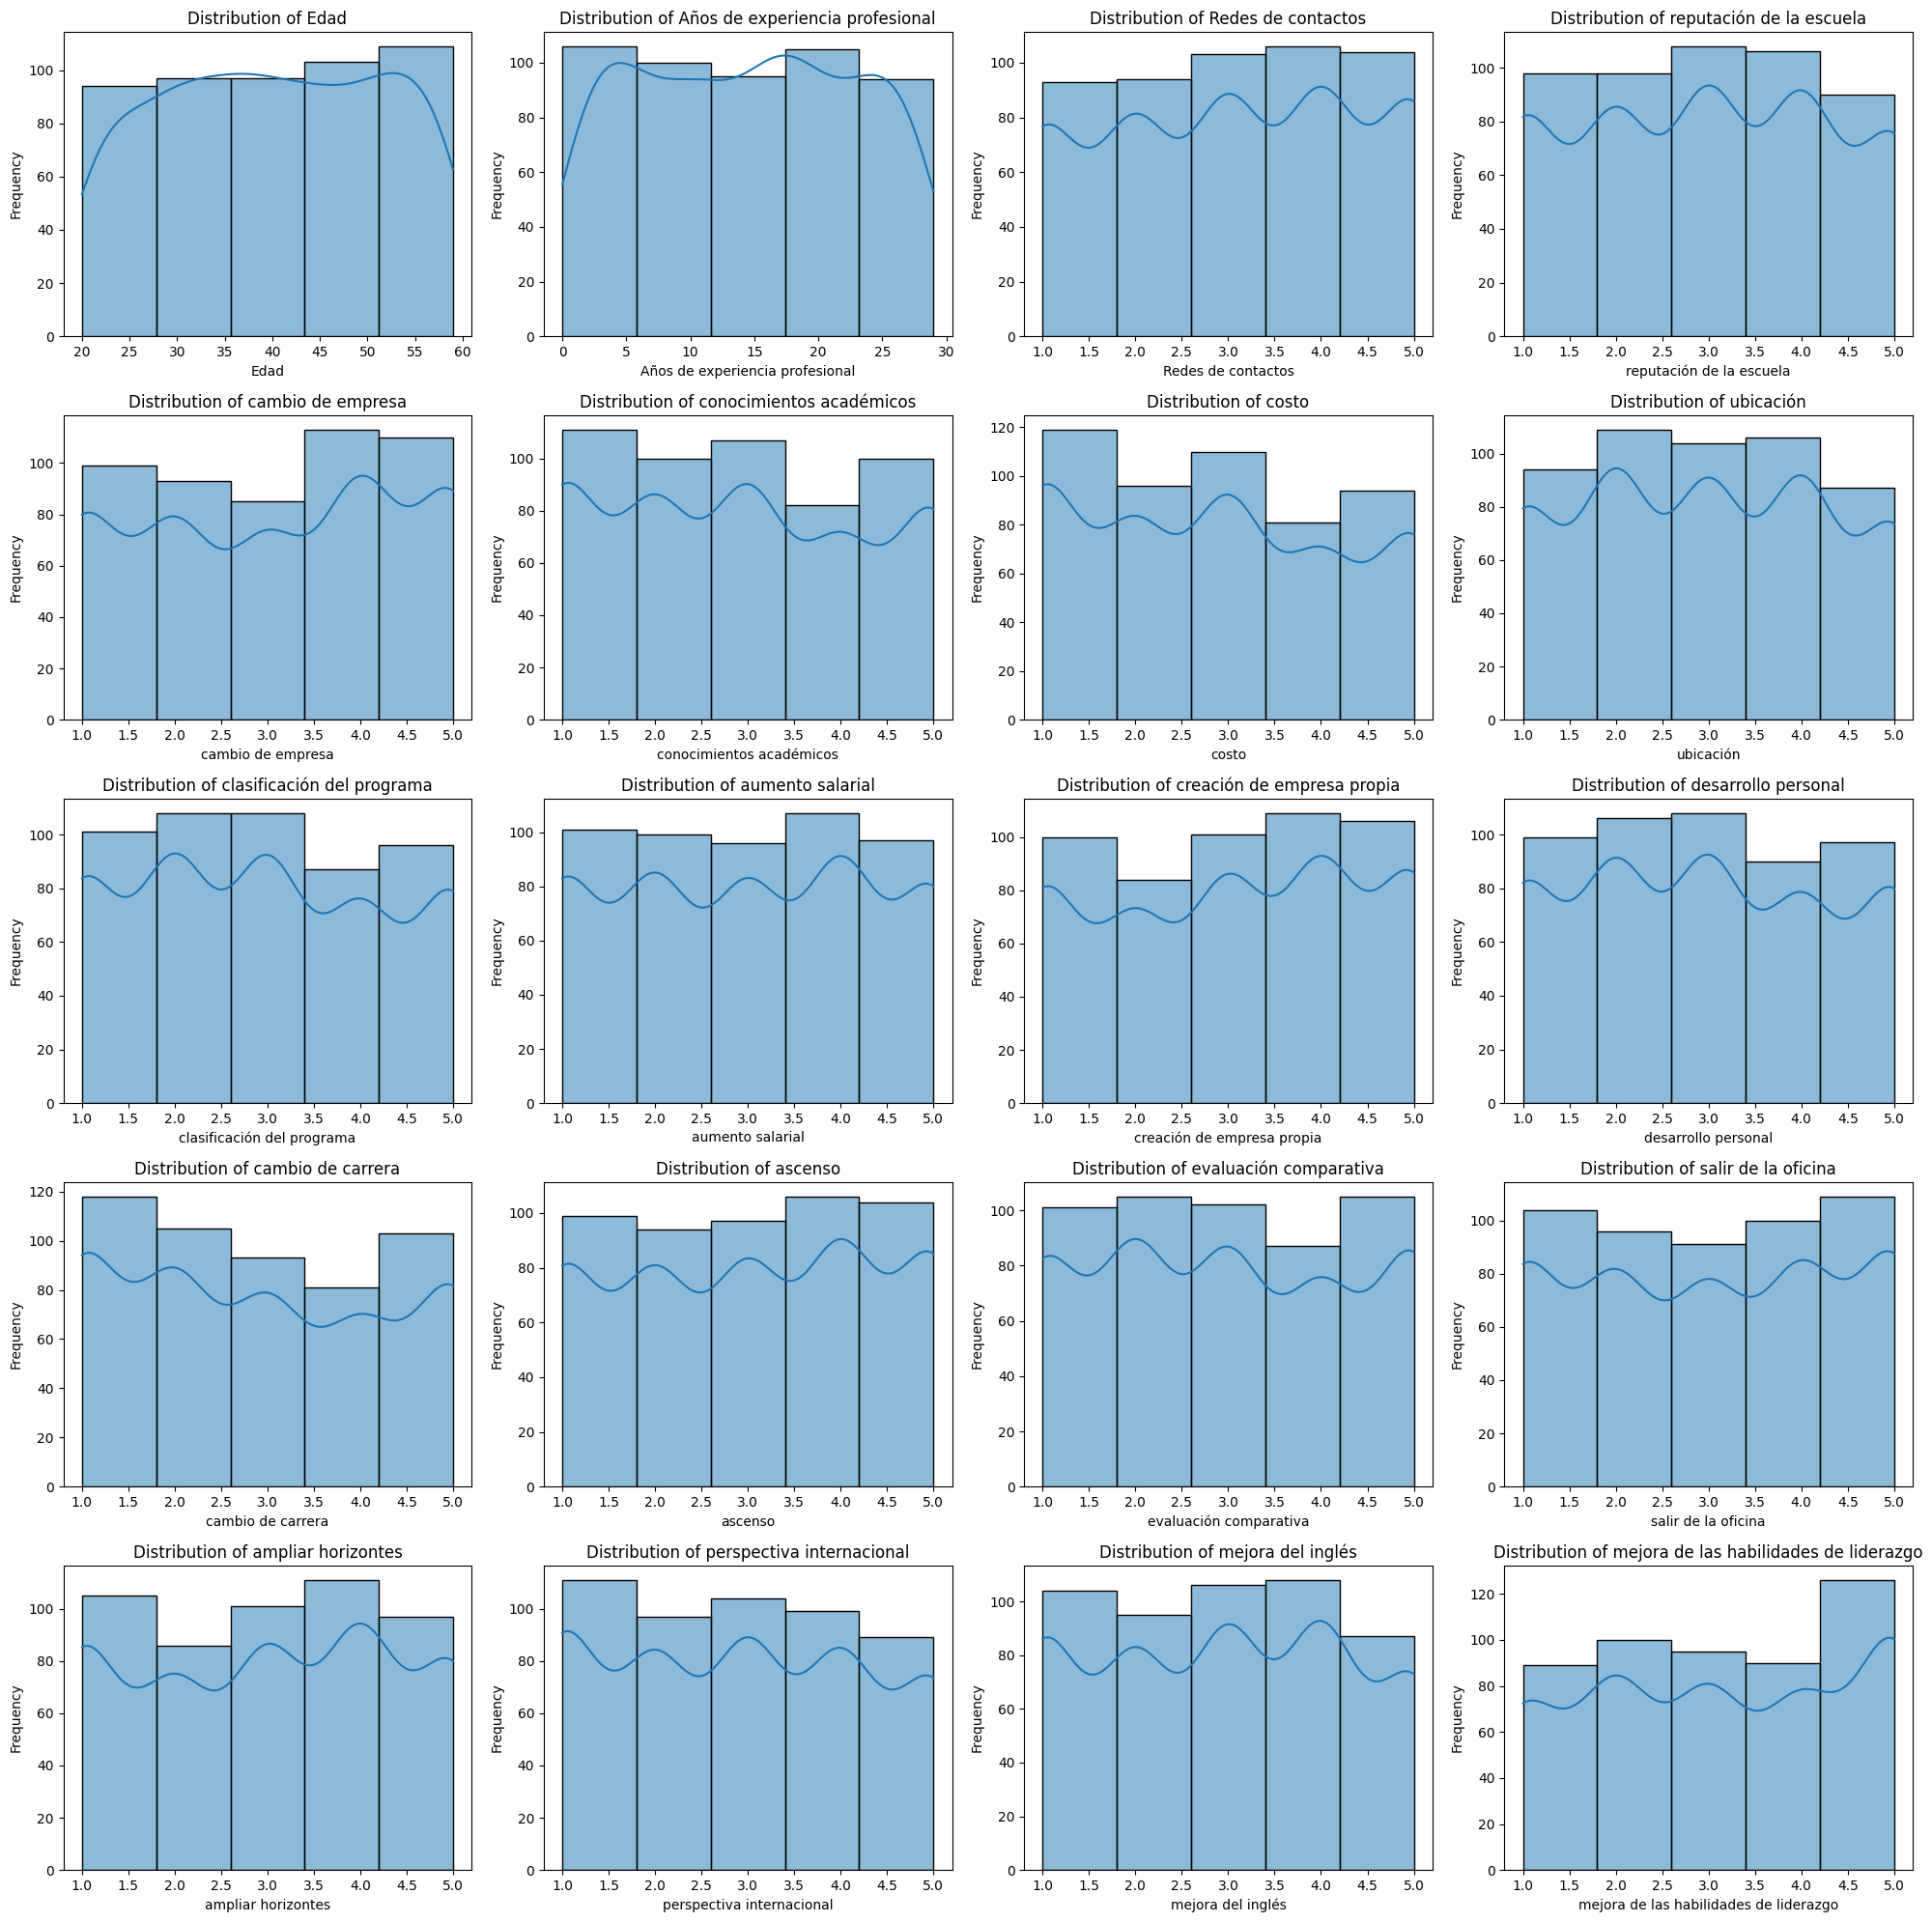

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for histograms
numerical_cols = ['Edad', 'Años de experiencia profesional'] + rating_aspects

# Plot histograms for numerical columns
print("\nHistograms for Numerical Columns:")

# Determine the number of rows and columns for the subplot grid
num_numerical_cols = len(numerical_cols)
n_cols = 4  # Number of columns in the grid
n_rows = (num_numerical_cols + n_cols - 1) // n_cols # Calculate number of rows needed

plt.figure(figsize=(n_cols * 5, n_rows * 4))
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df_sample[col], bins=5, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 3. Segmentación de Variables

Aquí se separa un DataFrame con las variables que serán utilizadas para la segmentación.

In [7]:
# Create a new DataFrame with only the rating aspects
df_segmentation = df_sample[rating_aspects]

print("DataFrame for Segmentation (first 5 rows):")
display(df_segmentation.head())

DataFrame for Segmentation (first 5 rows):


,Redes de contactos,reputación de la escuela,cambio de empresa,conocimientos académicos,costo,ubicación,clasificación del programa,aumento salarial,creación de empresa propia,desarrollo personal,cambio de carrera,ascenso,evaluación comparativa,salir de la oficina,ampliar horizontes,perspectiva internacional,mejora del inglés,mejora de las habilidades de liderazgo
0,3,1,1,1,1,5,4,2,1,1,3,5,2,1,4,3,4,2
1,1,1,5,4,1,2,1,2,3,1,1,4,4,2,1,2,5,2
2,3,2,3,4,4,1,3,4,4,2,1,3,1,3,3,4,5,2
3,3,3,2,3,5,2,1,4,3,2,2,5,2,1,3,5,2,2
4,2,1,1,5,1,2,1,4,4,3,5,3,5,2,5,1,3,5


## 4. Estandarización de Variables de Segmentación

Las variables de segmentación se estandarizan usando Min-Max Scaling para que varíen entre 0 y 1. Esto es útil para muchos algoritmos de machine learning que son sensibles a la escala de las variables.

In [8]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Apply Min-Max scaling to the segmentation DataFrame
df_segmentation_scaled = pd.DataFrame(scaler.fit_transform(df_segmentation), columns=df_segmentation.columns)

print("Standardized Segmentation Data (first 5 rows):")
display(df_segmentation_scaled.head())

Standardized Segmentation Data (first 5 rows):


,Redes de contactos,reputación de la escuela,cambio de empresa,conocimientos académicos,costo,ubicación,clasificación del programa,aumento salarial,creación de empresa propia,desarrollo personal,cambio de carrera,ascenso,evaluación comparativa,salir de la oficina,ampliar horizontes,perspectiva internacional,mejora del inglés,mejora de las habilidades de liderazgo
0,0.50,0.00,0.00,0.00,0.00,1.00,0.75,0.25,0.00,0.00,0.50,1.00,0.25,0.00,0.75,0.50,0.75,0.25
1,0.00,0.00,1.00,0.75,0.00,0.25,0.00,0.25,0.50,0.00,0.00,0.75,0.75,0.25,0.00,0.25,1.00,0.25
2,0.50,0.25,0.50,0.75,0.75,0.00,0.50,0.75,0.75,0.25,0.00,0.50,0.00,0.50,0.50,0.75,1.00,0.25
3,0.50,0.50,0.25,0.50,1.00,0.25,0.00,0.75,0.50,0.25,0.25,1.00,0.25,0.00,0.50,1.00,0.25,0.25
4,0.25,0.00,0.00,1.00,0.00,0.25,0.00,0.75,0.75,0.50,1.00,0.50,1.00,0.25,1.00,0.00,0.50,1.00


## 5. Clusterización con K-Means y Evaluación del Número de Clusters

Se realizará la clusterización con K-Means y se evaluará el número óptimo de clusters utilizando el método del codo (Elbow Method) y el coeficiente Silhouette.

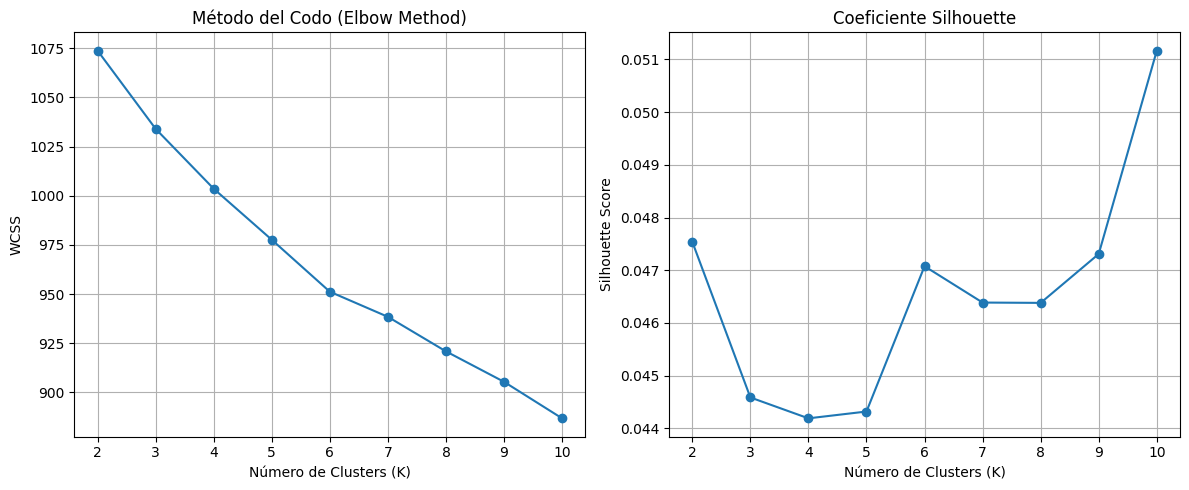

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set a range for the number of clusters to evaluate
k_range = range(2, 11)

wcss = [] # Within-Cluster Sum of Squares
silhouette_scores = []

# Run K-Means for each K and calculate WCSS and Silhouette Score
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_segmentation_scaled)
    wcss.append(kmeans.inertia_)

    # Calculate Silhouette Score (only if k > 1)
    if k > 1:
        score = silhouette_score(df_segmentation_scaled, kmeans.labels_)
        silhouette_scores.append(score)

# Plot the Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker='o')
plt.title('Método del Codo (Elbow Method)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)

# Plot the Silhouette Scores
plt.subplot(1, 2, 2)
# Adjust k_range for silhouette_scores as it starts from k=2
plt.plot(k_range[0:], silhouette_scores, marker='o')
plt.title('Coeficiente Silhouette')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

### Interpretación de los Resultados:

*   **Método del Codo (Elbow Method):** Buscamos el punto en el gráfico de WCSS donde la disminución en la inercia (WCSS) comienza a ralentizarse, formando una especie de 'codo'. Este punto sugiere un buen equilibrio entre la compacidad de los clusters y la cantidad de clusters.

*   **Coeficiente Silhouette:** Un valor alto del coeficiente Silhouette indica que los objetos están bien emparejados con su propio cluster y mal emparejados con clusters vecinos. Los valores oscilan entre -1 y 1, donde un valor cercano a 1 indica clusters bien separados, un valor cercano a 0 indica solapamiento entre clusters y un valor negativo indica que los objetos pueden haber sido asignados al cluster incorrecto.

Observando ambos gráficos, el número de clusters más adecuado para este problema será aquel que muestre un 'codo' claro en el método del codo y un pico (o un valor alto consistente) en el coeficiente Silhouette.

## 6. Descripción de los Clusters

In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Perform K-Means clustering with K=6 (as decided for demonstration)
num_clusters = 6
kmeans_model = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
kmeans_model.fit(df_segmentation_scaled)

# Add the cluster labels to the original (unscaled) segmentation DataFrame
df_segmentation_with_clusters = df_segmentation.copy()
df_segmentation_with_clusters['Cluster'] = kmeans_model.labels_

# Calculate the mean of the original (unscaled) segmentation variables for each cluster
cluster_profiles = df_segmentation_with_clusters.groupby('Cluster')[rating_aspects].mean()

print("Cluster Profiles (Mean of Original Ratings per Cluster):")
display(cluster_profiles)

Cluster Profiles (Mean of Original Ratings per Cluster):


,Redes de contactos,reputación de la escuela,cambio de empresa,conocimientos académicos,costo,ubicación,clasificación del programa,aumento salarial,creación de empresa propia,desarrollo personal,cambio de carrera,ascenso,evaluación comparativa,salir de la oficina,ampliar horizontes,perspectiva internacional,mejora del inglés,mejora de las habilidades de liderazgo
Cluster,,,,,,,,,,,,,,,,,,
0,2.886364,3.795455,3.102273,2.125000,2.875000,2.602273,3.022727,2.431818,3.238636,1.988636,3.897727,3.443182,2.477273,3.079545,2.954545,2.352273,3.045455,4.238636
1,3.636364,3.170455,2.568182,3.465909,3.284091,2.965909,2.329545,2.420455,3.329545,2.704545,3.045455,3.409091,2.454545,2.306818,3.352273,3.329545,2.738636,1.829545
2,2.250000,2.062500,2.512500,3.612500,2.387500,3.150000,3.687500,2.925000,3.937500,2.687500,2.962500,2.975000,3.412500,3.325000,3.775000,3.187500,3.650000,3.637500
3,1.971831,3.211268,3.253521,2.816901,2.577465,2.492958,2.014085,3.633803,3.577465,3.647887,1.915493,3.492958,3.197183,3.647887,3.126761,2.521127,1.746479,3.028169
4,3.298851,3.045977,3.862069,3.022989,2.333333,3.000000,3.827586,3.540230,2.057471,2.931034,2.804598,2.885057,3.620690,2.678161,1.896552,2.862069,3.218391,2.206897
5,4.104651,2.569767,3.197674,2.511628,3.674419,3.523256,2.639535,3.174419,2.453488,3.930233,2.534884,2.116279,2.802326,3.279070,3.081395,3.197674,3.186047,3.860465


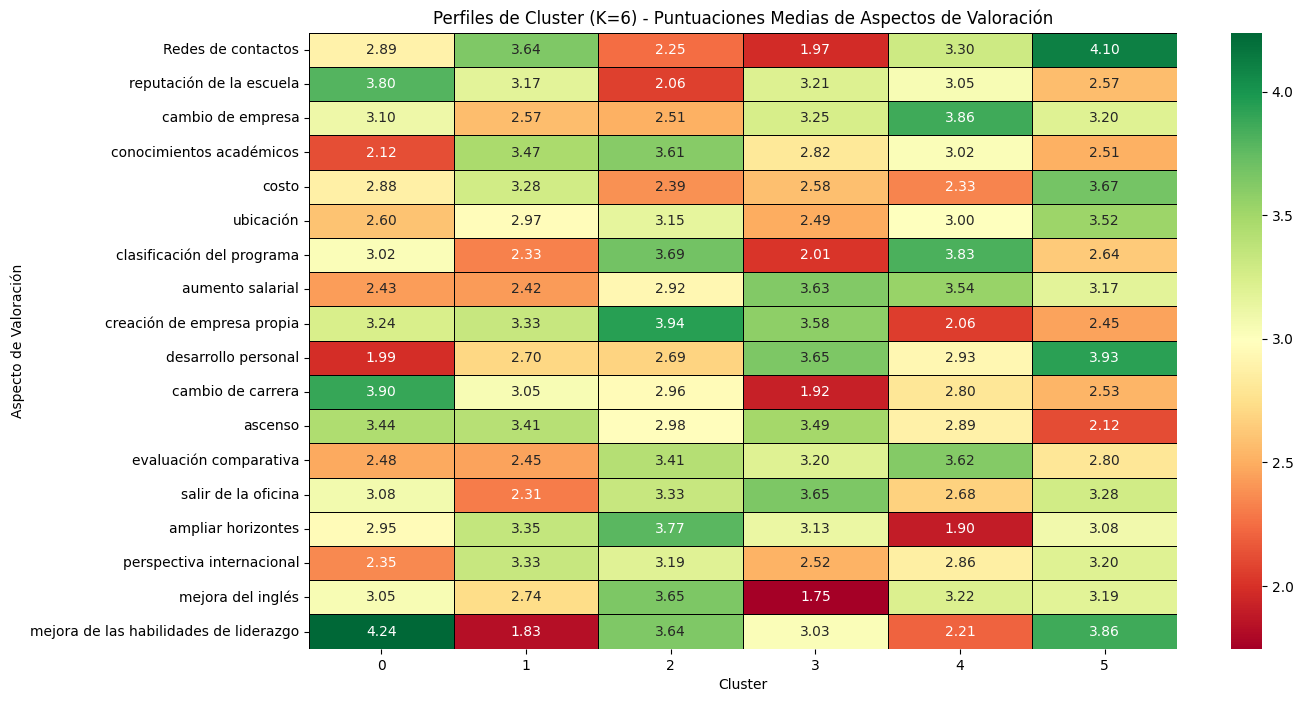

In [11]:
# Visualize cluster profiles using a heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(cluster_profiles.T, cmap='RdYlGn', annot=True, fmt=".2f", linewidths=.5, linecolor='black')
plt.title(f'Perfiles de Cluster (K={num_clusters}) - Puntuaciones Medias de Aspectos de Valoración')
plt.xlabel('Cluster')
plt.ylabel('Aspecto de Valoración')
plt.yticks(rotation=0)
plt.show()

## 7. Nombres y Representaciones Visuales de los Segmentos

### Segmento 0: El León Estratega

**Descripción:** Individuos enfocados en el liderazgo y el cambio de carrera, utilizando la reputación de la escuela como un trampolín. Son ambiciosos y buscan una transformación profesional guiada por objetivos claros, con menos énfasis en el desarrollo personal genérico. Al igual que un león que lidera su manada y busca nuevos territorios, estos individuos están impulsados por el ascenso y la influencia.

**Imagen:** Un león majestuoso con una mirada decidida, quizás con un fondo de un gráfico de crecimiento o una silueta de una ciudad.



### Segmento 1: La Mariposa Global

**Descripción:** Este grupo se distingue por su deseo de establecer amplias redes de contactos y una perspectiva internacional, con un interés notable en la creación de empresa propia. Son curiosos, adaptables y buscan expandir sus horizontes más allá de las fronteras tradicionales, con un espíritu emprendedor que no se detiene ante los límites. La mariposa, con su capacidad de viajar y su naturaleza de transformación, representa bien este espíritu global y en constante evolución.

**Imagen:** Una mariposa colorida volando sobre un mapa mundi estilizado, dejando un rastro de conexiones y con pequeños íconos de emprendimiento.



### Segmento 2: El Halcón Emprendedor

**Descripción:** Miembros de este segmento son visionarios, priorizando la creación de empresa propia y el desarrollo de habilidades clave como el liderazgo y el dominio del inglés, valorando la excelencia académica. Buscan destacarse y construir su propio camino, con una visión clara de lo que necesitan para lograr la autonomía y el éxito. El halcón, con su aguda visión y su capacidad de volar alto para identificar oportunidades, simboliza la independencia y el enfoque de este segmento.

**Imagen:** Un halcón en pleno vuelo, con un ojo enfocado en un punto distante en el horizonte, y herramientas de aprendizaje o logos de startups en el fondo.



### Segmento 3: El Oso Contento

**Descripción:** Este segmento se enfoca en el desarrollo personal y el aumento salarial, buscando mejorar sus condiciones de vida y obtener reconocimiento a través del ascenso, sin un interés significativo en cambios drásticos de carrera o nuevas habilidades lingüísticas. Son individuos que valoran la estabilidad y el crecimiento continuo dentro de su entorno actual. El oso, que busca la comodidad y la prosperidad en su hábitat, representa la búsqueda de bienestar y el crecimiento constante en su propio entorno.

**Imagen:** Un oso fuerte y satisfecho en un entorno acogedor, con símbolos de crecimiento personal y éxito financiero alrededor, como libros o un gráfico ascendente.



### Segmento 4: El Lobo de Wall Street

**Descripción:** Este grupo se caracteriza por su mentalidad estratégica y competitiva, buscando constantemente el cambio de empresa, la evaluación comparativa y el aumento salarial para progresar en el mercado laboral. Son pragmáticos y orientados a resultados, con una clara ambición de escalar posiciones en el mundo corporativo. El lobo, conocido por su inteligencia táctica y su búsqueda implacable de la presa, representa la astucia y la competitividad de este segmento en el entorno empresarial.

**Imagen:** Un lobo con un traje de negocios, mirando fijamente un gráfico bursátil o un organigrama de empresa, con un fondo de rascacielos.



### Segmento 5: La Abeja Comunitaria

**Descripción:** Individuos que valoran las redes de contactos y el desarrollo personal y de liderazgo, con una fuerte consideración por factores prácticos como el costo y la ubicación. Son colaborativos y buscan crecer dentro de una comunidad o red, optimizando su inversión en desarrollo. La abeja, un insecto social y trabajador que contribuye al bienestar de su colmena, simboliza el espíritu comunitario y la búsqueda de crecimiento mutuo de este segmento.

**Imagen:** Un grupo de abejas trabajando juntas en una colmena, con hilos de conexión entre ellas y símbolos de desarrollo personal y liderazgo (como una corona pequeña o un megáfono).



## 8. Distribución de Individuos por Segmento

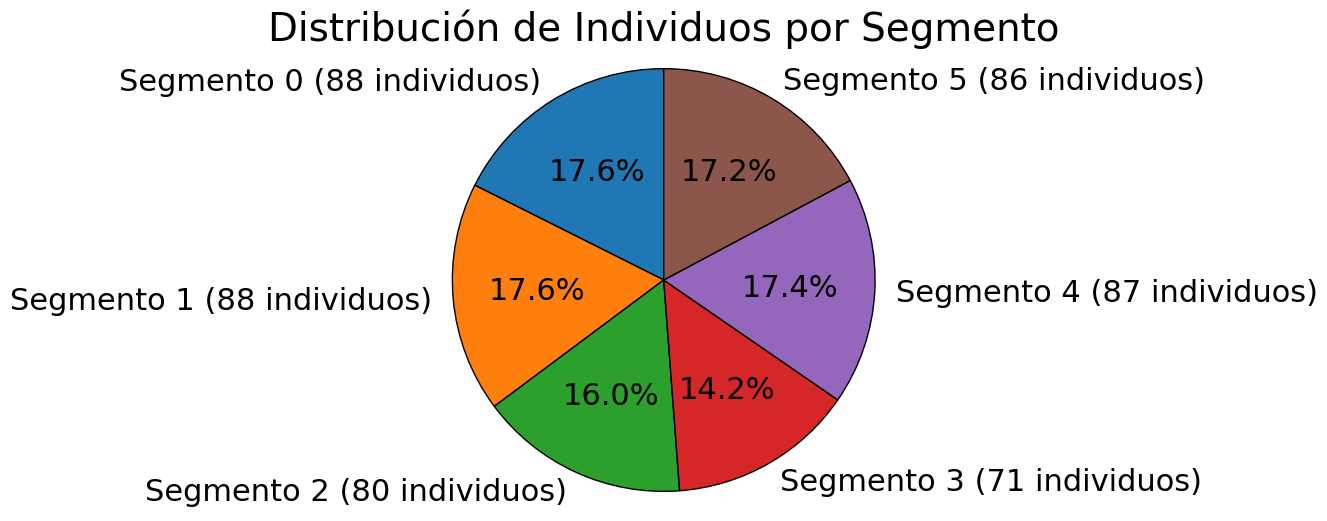

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the size of each cluster
cluster_counts = df_segmentation_with_clusters['Cluster'].value_counts().sort_index()

# Calculate the percentage of each cluster
cluster_percentages = (cluster_counts / len(df_segmentation_with_clusters)) * 100

# Prepare labels for the pie chart
pie_labels = [f'Segmento {i} ({count} individuos)'
              for i, (count, percentage) in enumerate(zip(cluster_counts, cluster_percentages))]

# Create the pie chart
plt.figure(figsize=(6, 6)) # Further decreased figure size to make the pie even smaller
plt.pie(cluster_counts, labels=pie_labels,
        autopct=lambda p: '{:.1f}%'.format(p),
        startangle=90, wedgeprops={'edgecolor': 'black'},
        textprops={'fontsize': 22}) # Significantly increased font size for labels again
plt.title('Distribución de Individuos por Segmento', fontsize=28) # Significantly increased font size for title again
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()